In [1]:
!pip install ctgan

In [2]:
!pip install table_evaluator

In [24]:
import numpy as np
import pandas as pd
import ctgan
np.random.seed(42)
ins = pd.read_csv('/content/sample_data/insurance_dataset.csv')
discrete_columns = [
    'gender',
    'smoker',
    'region',
]
print(ins.shape)

(1338, 7)


In [23]:

generador = ctgan.CTGAN(verbose=True,batch_size=50,discriminator_steps=3,pac=5)
generador.fit(ins, discrete_columns,epochs=150)
generador.save('/content/sample_data/insurance_dataset_ctgan.pk1') # pk1 pickel format for neural network serialization
samples = generador.sample(200)
samples.to_csv('/content/sample_data/insurance_dataset_ctgan.csv', index=False)
# age and children are integers in your real data, but CTGAN treats them as continuous and will generate floats (e.g. age = 34.7).
samples['age'] = samples['age'].round().astype(int)
samples['children'] = samples['children'].round().clip(lower=0).astype(int)

Gen. (-00.92) | Discrim. (-00.22): 100%|██████████| 150/150 [03:25<00:00,  1.37s/it]


<Axes: xlabel='Epoch'>

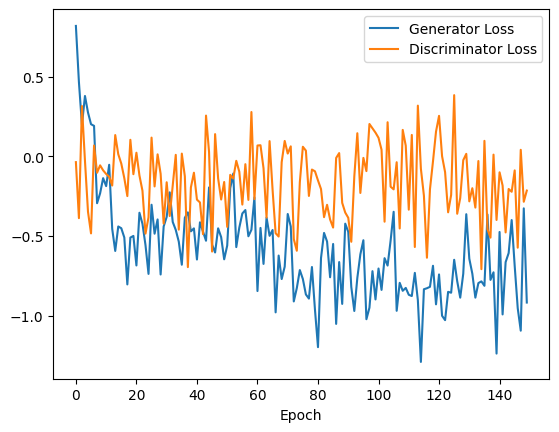

In [25]:
# Check convergence, don't just trust epochs. Capture the loss values and plot them:
losses = generador.loss_values  # DataFrame with Generator/Discriminator loss per epoch
losses.plot(x='Epoch', y=['Generator Loss', 'Discriminator Loss'])

In [26]:
# Nothing currently verifies the fake data actually resembles the real data. At minimum:
print(ins.describe())
print(samples.describe())
print("---------------------------------------------------")
print(ins[discrete_columns].apply(lambda x: x.value_counts(normalize=True)))
print(samples[discrete_columns].apply(lambda x: x.value_counts(normalize=True)))

               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.915000
max      64.000000    53.100000     5.000000  63770.430000
              age         bmi    children      expenses
count  200.000000  200.000000  200.000000    200.000000
mean    37.725000   29.896148    1.050000  13912.916229
std     13.466481    5.788842    1.050245  13449.112711
min     13.000000   18.201064    0.000000   -513.288013
25%     25.000000   26.176182    0.000000   4512.920339
50%     38.000000   30.276571    1.000000   8941.297158
75%     48.000000   34.221405    1.000000  19372.159629
max     65.000000   4

In [28]:
from scipy.stats import chisquare
for col in discrete_columns:
    real_counts = ins[col].value_counts()
    synth_counts = samples[col].value_counts(normalize=True) * real_counts.sum()
    stat, p = chisquare(synth_counts.reindex(real_counts.index).fillna(0), real_counts)
    print(f"{col}: statistic={stat:.2f}, p-value={p:.2e}")

gender: statistic=0.51, p-value=4.75e-01
smoker: statistic=52.87, p-value=3.56e-13
region: statistic=32.05, p-value=5.11e-07


In [29]:
import table_evaluator

In [30]:
samples = generador.sample(1338)

In [31]:
print(ins.shape, samples.shape)

(1338, 7) (1338, 7)


In [32]:
evaluation = table_evaluator.TableEvaluator(ins, samples)

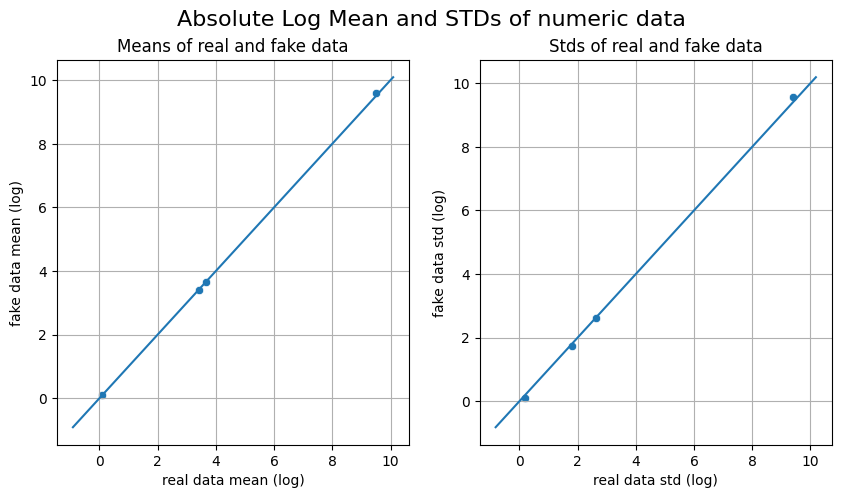

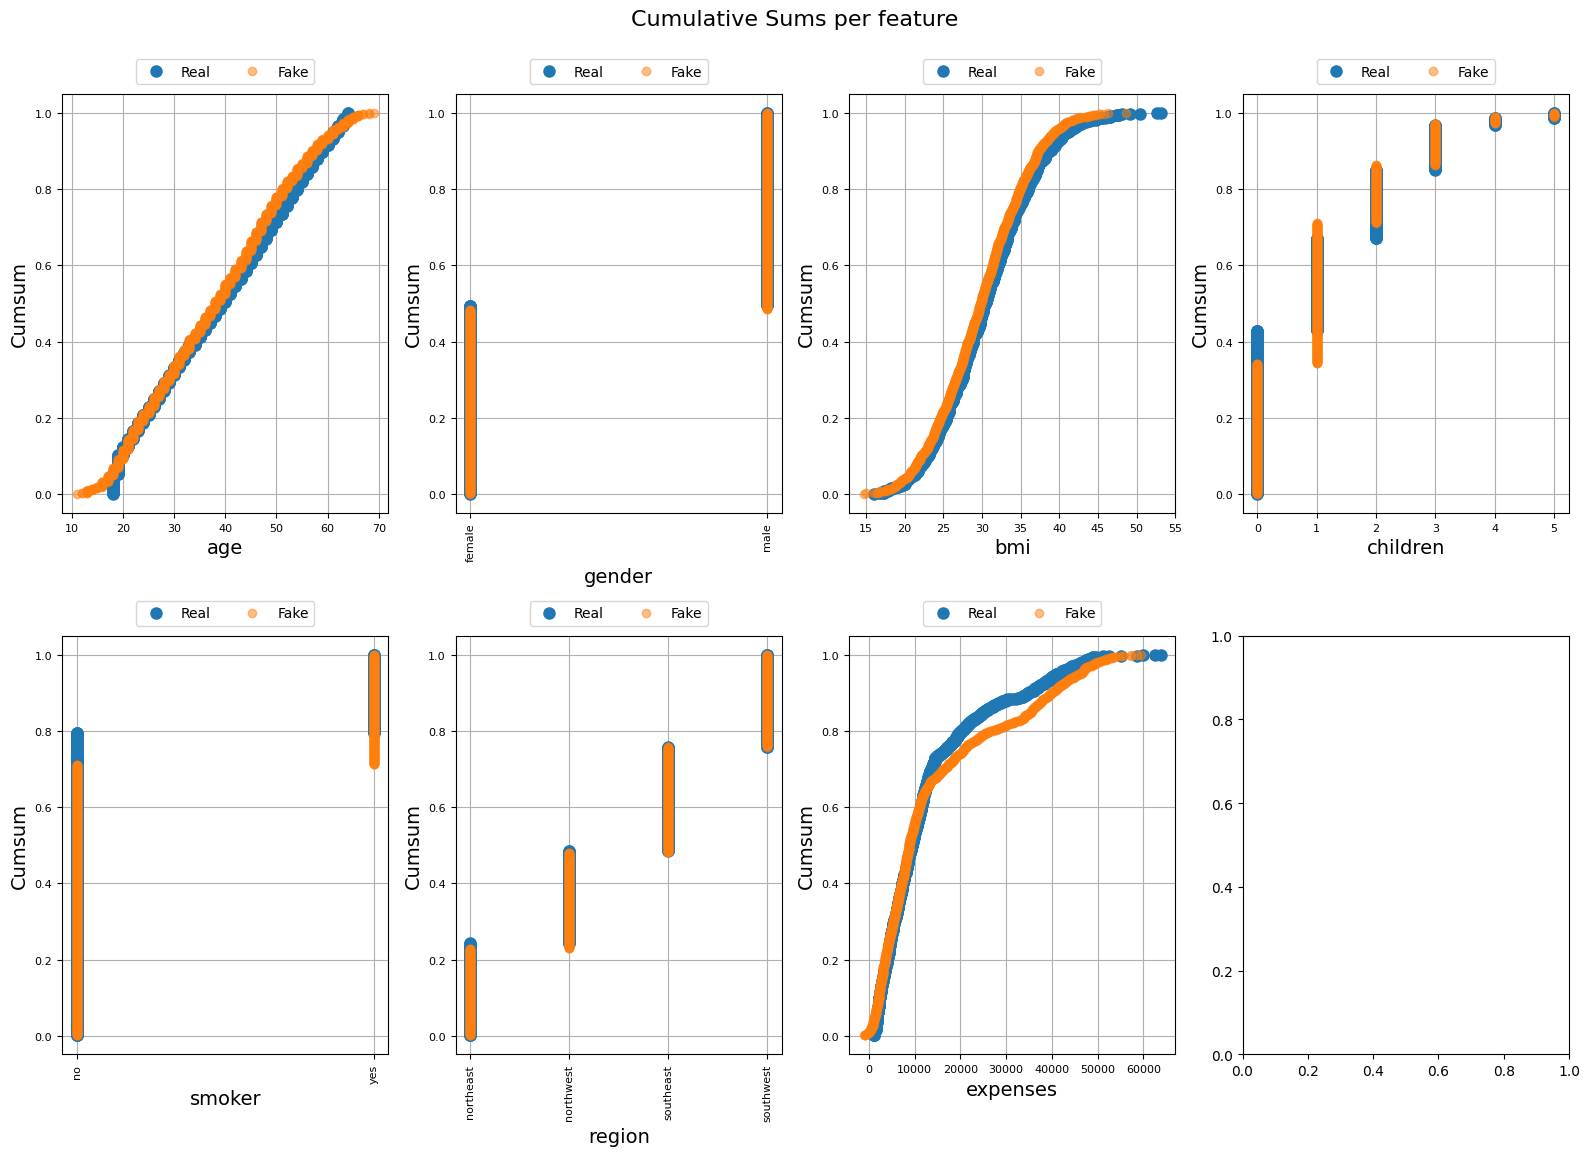

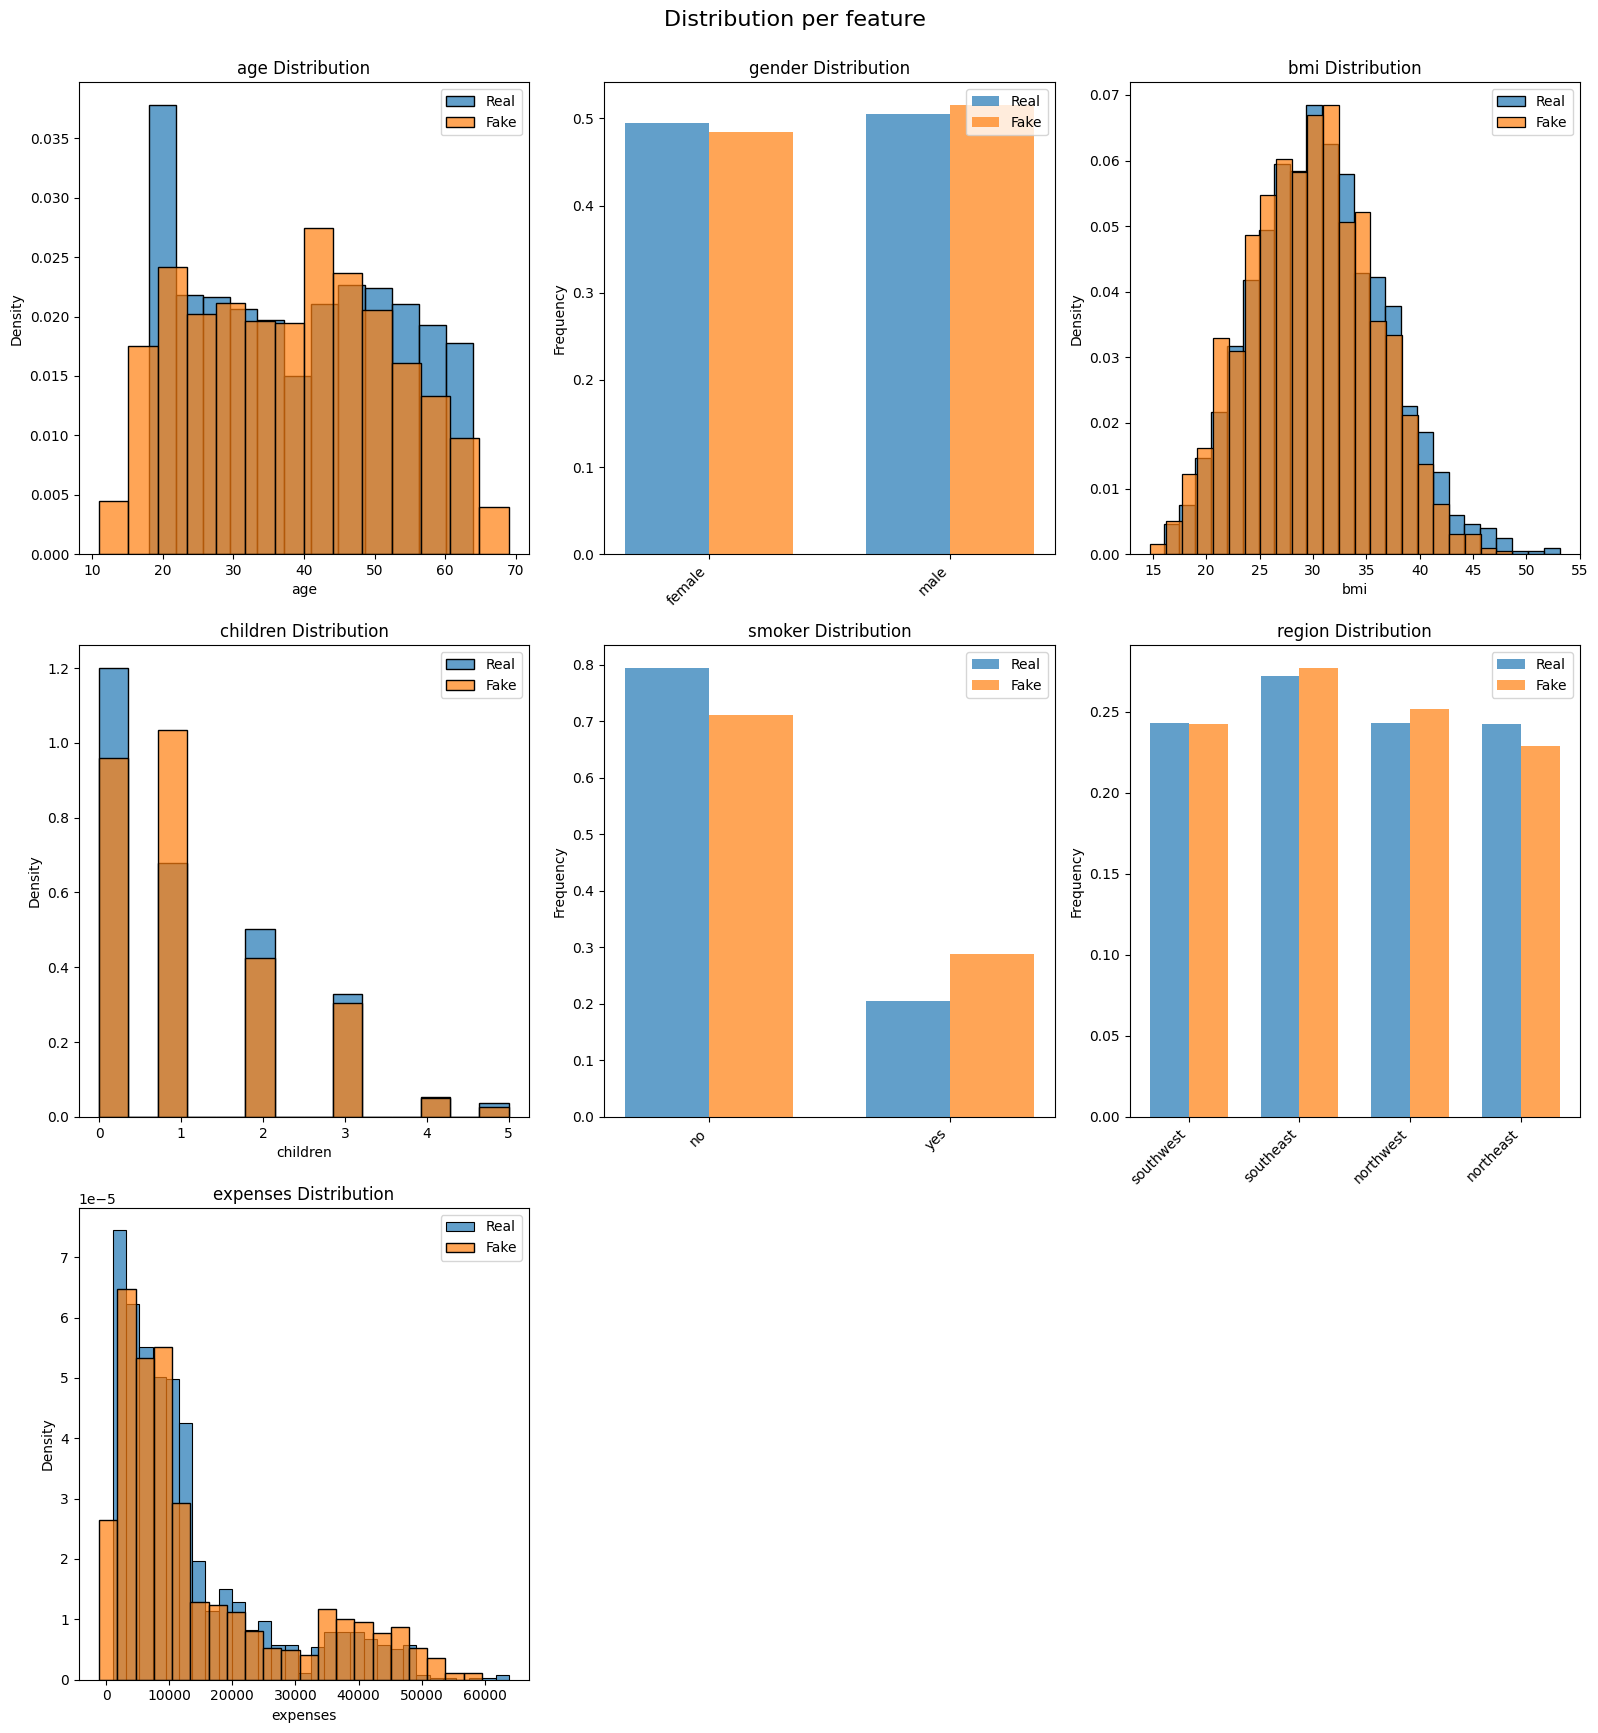

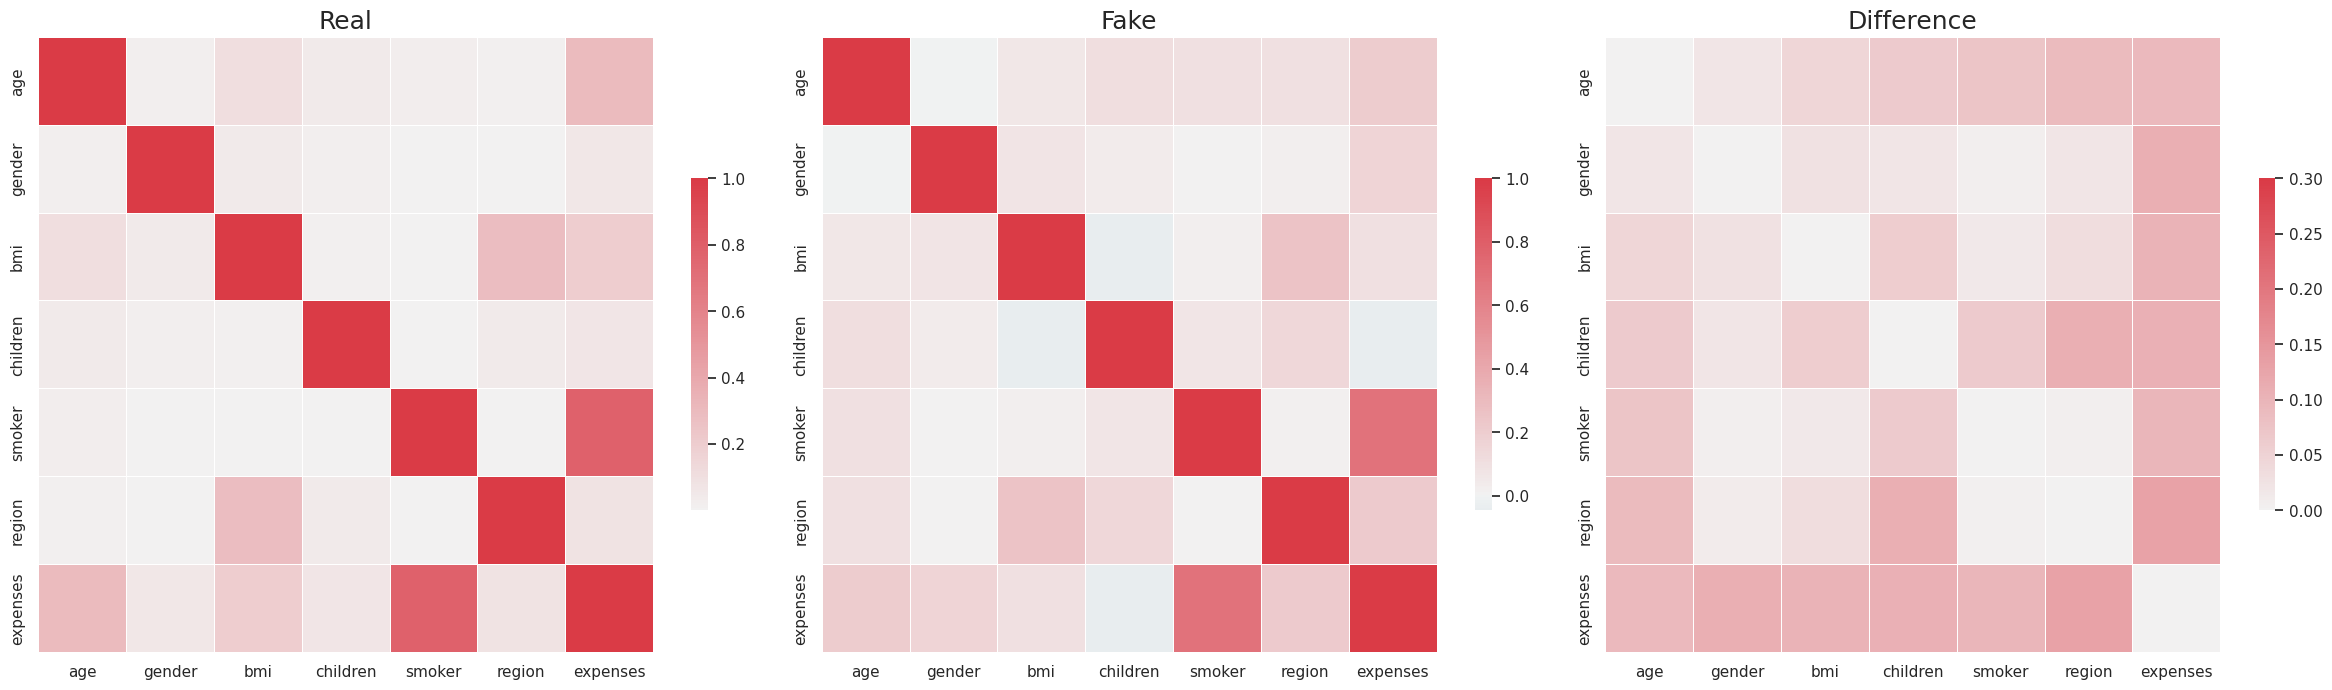

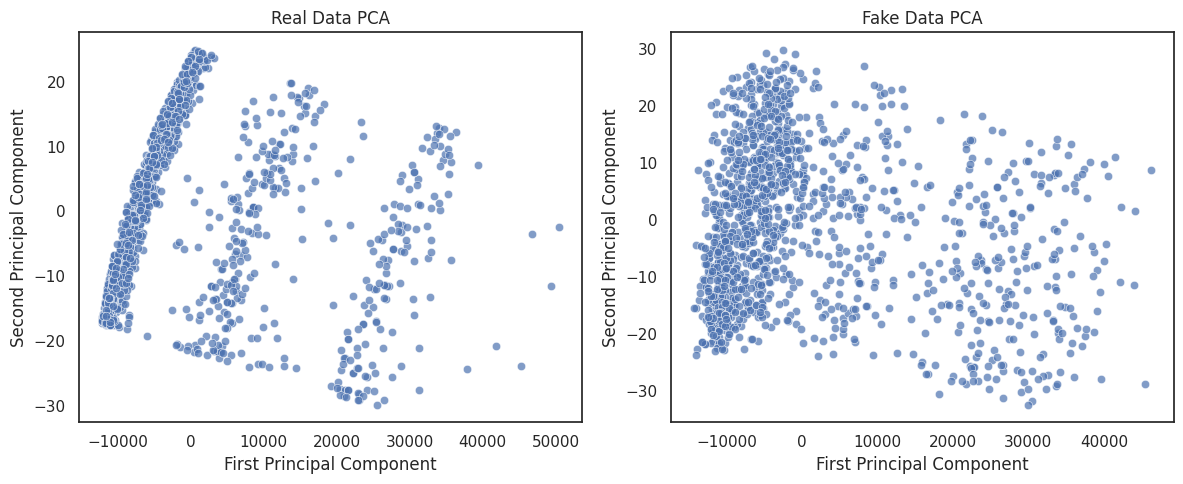

In [33]:
evaluation.visual_evaluation()

In [34]:

ins_syn = pd.read_csv('/content/sample_data/insurance_dataset_synthetic_howto.csv')  #  Created with howtocsv.com
ins_syn_fab = pd.read_csv('/content/sample_data/insurance_dataset_synthetic_Tonic_fabricate.csv')  #  Created with Tonic Fabricate

In [35]:
print(ins.shape, ins_syn.shape, ins_syn_fab.shape)

(1338, 7) (2676, 7) (1000, 7)


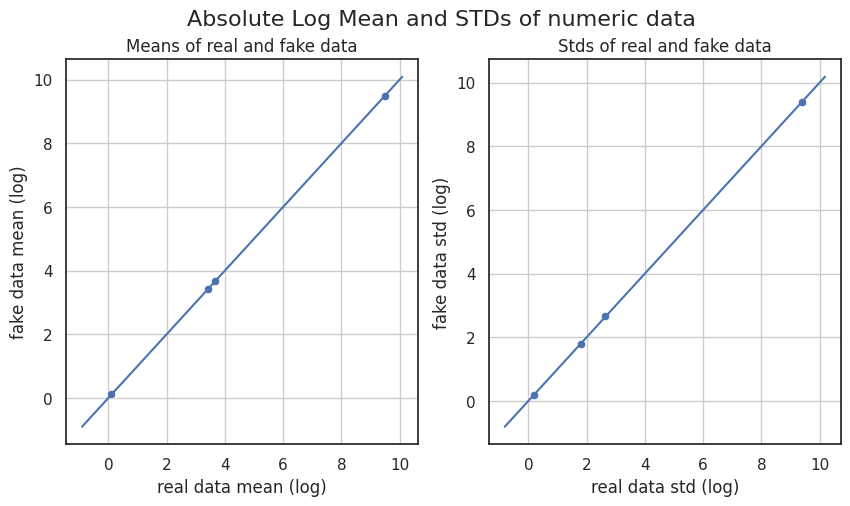

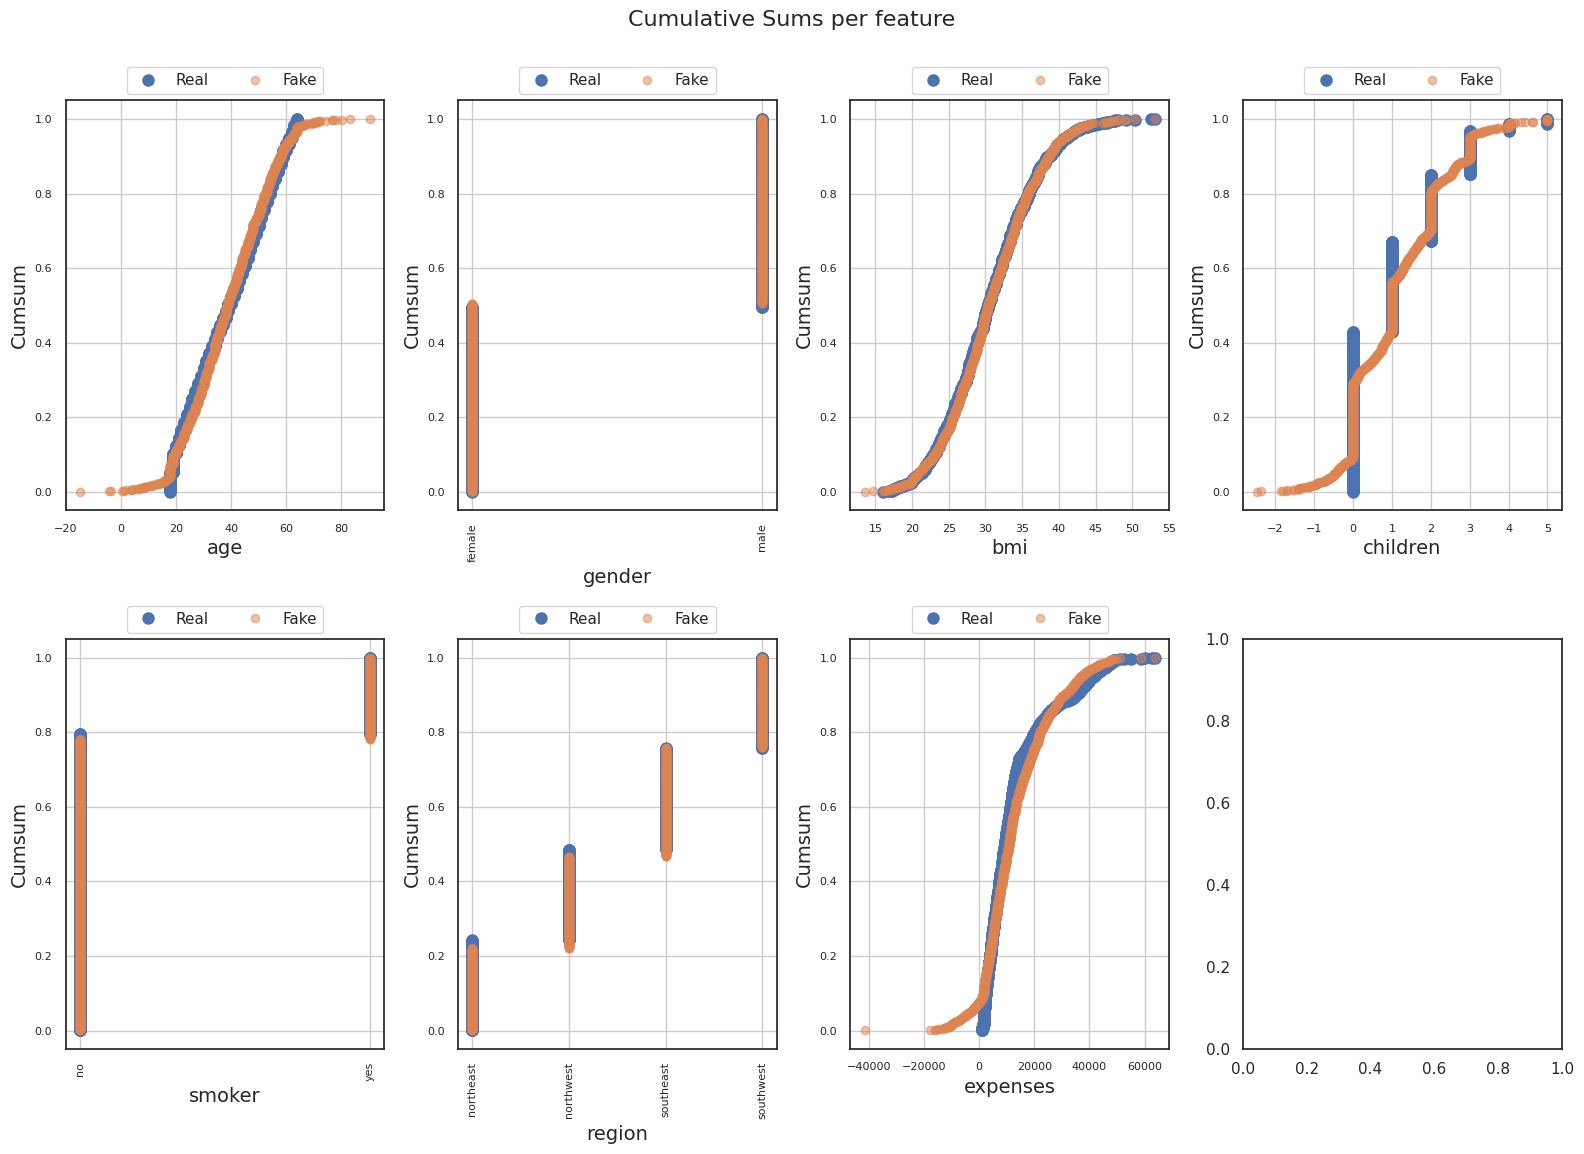

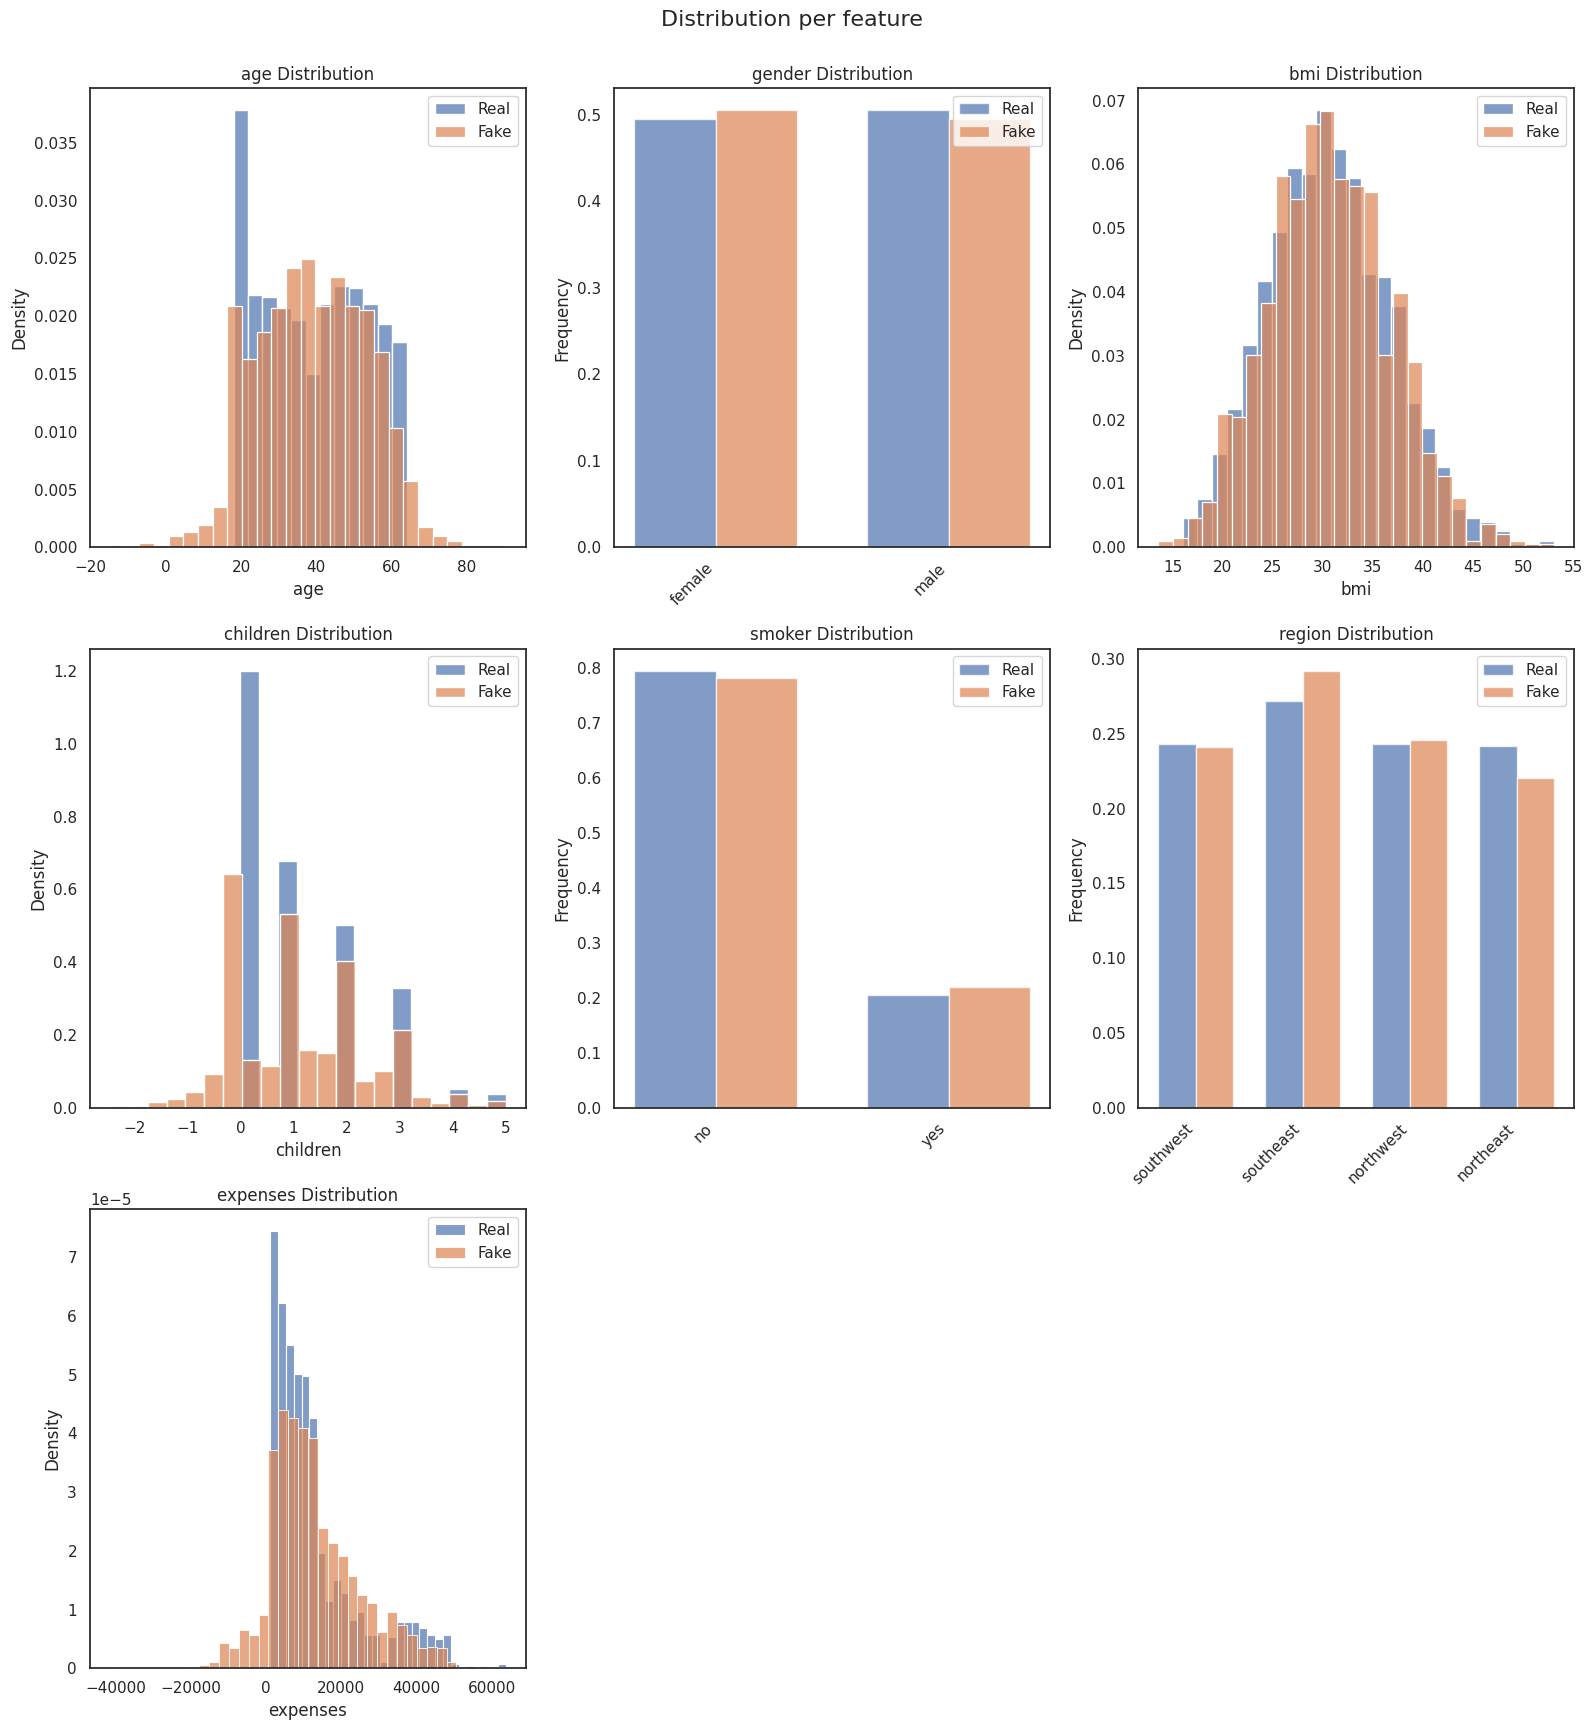

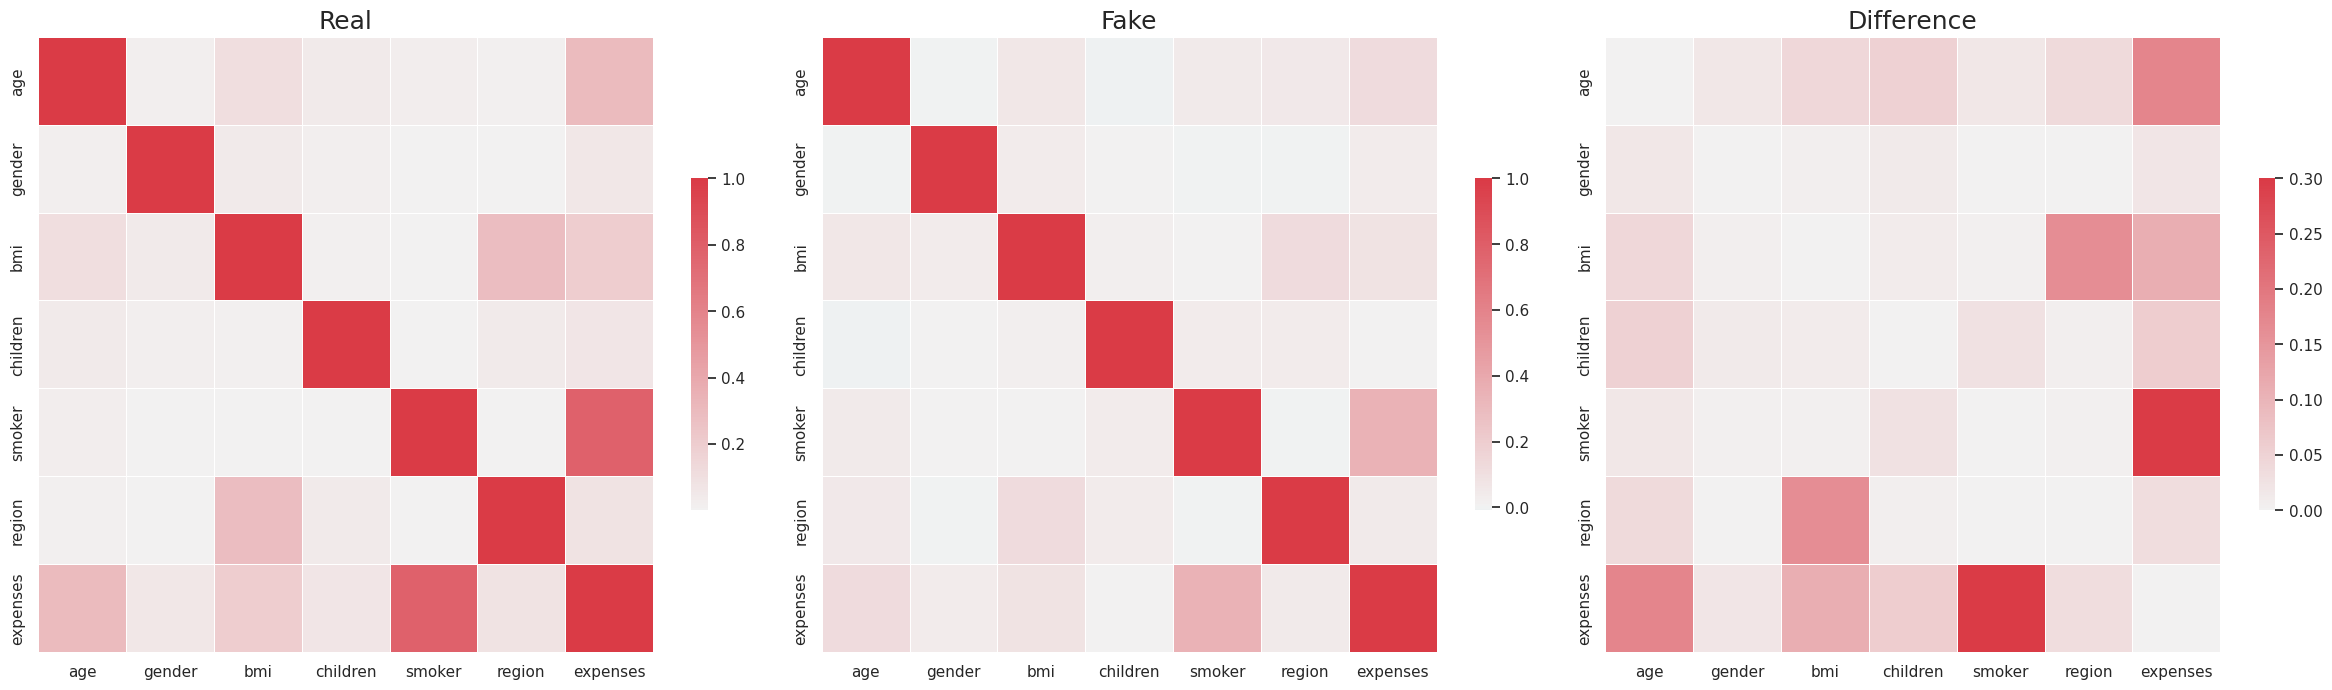

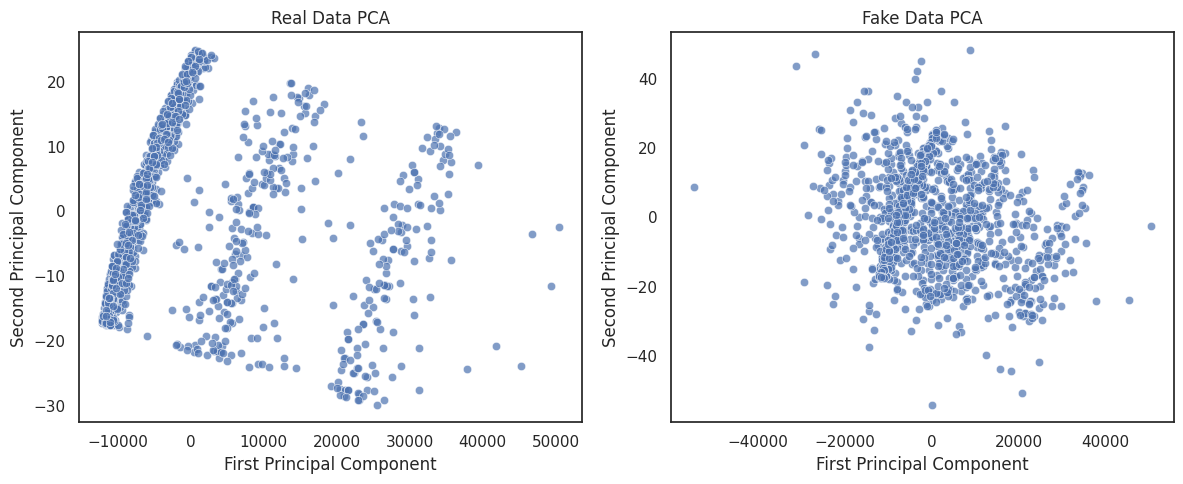

In [36]:
evaluation = table_evaluator.TableEvaluator(ins, ins_syn)
evaluation.visual_evaluation()

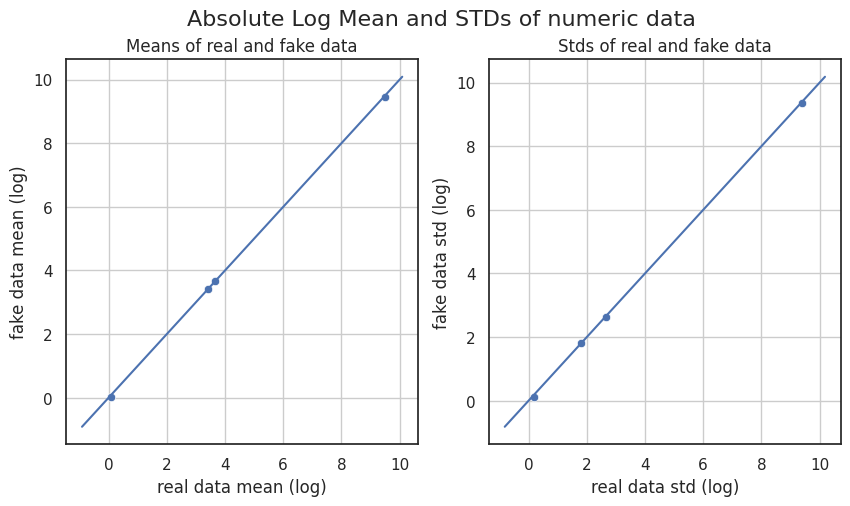

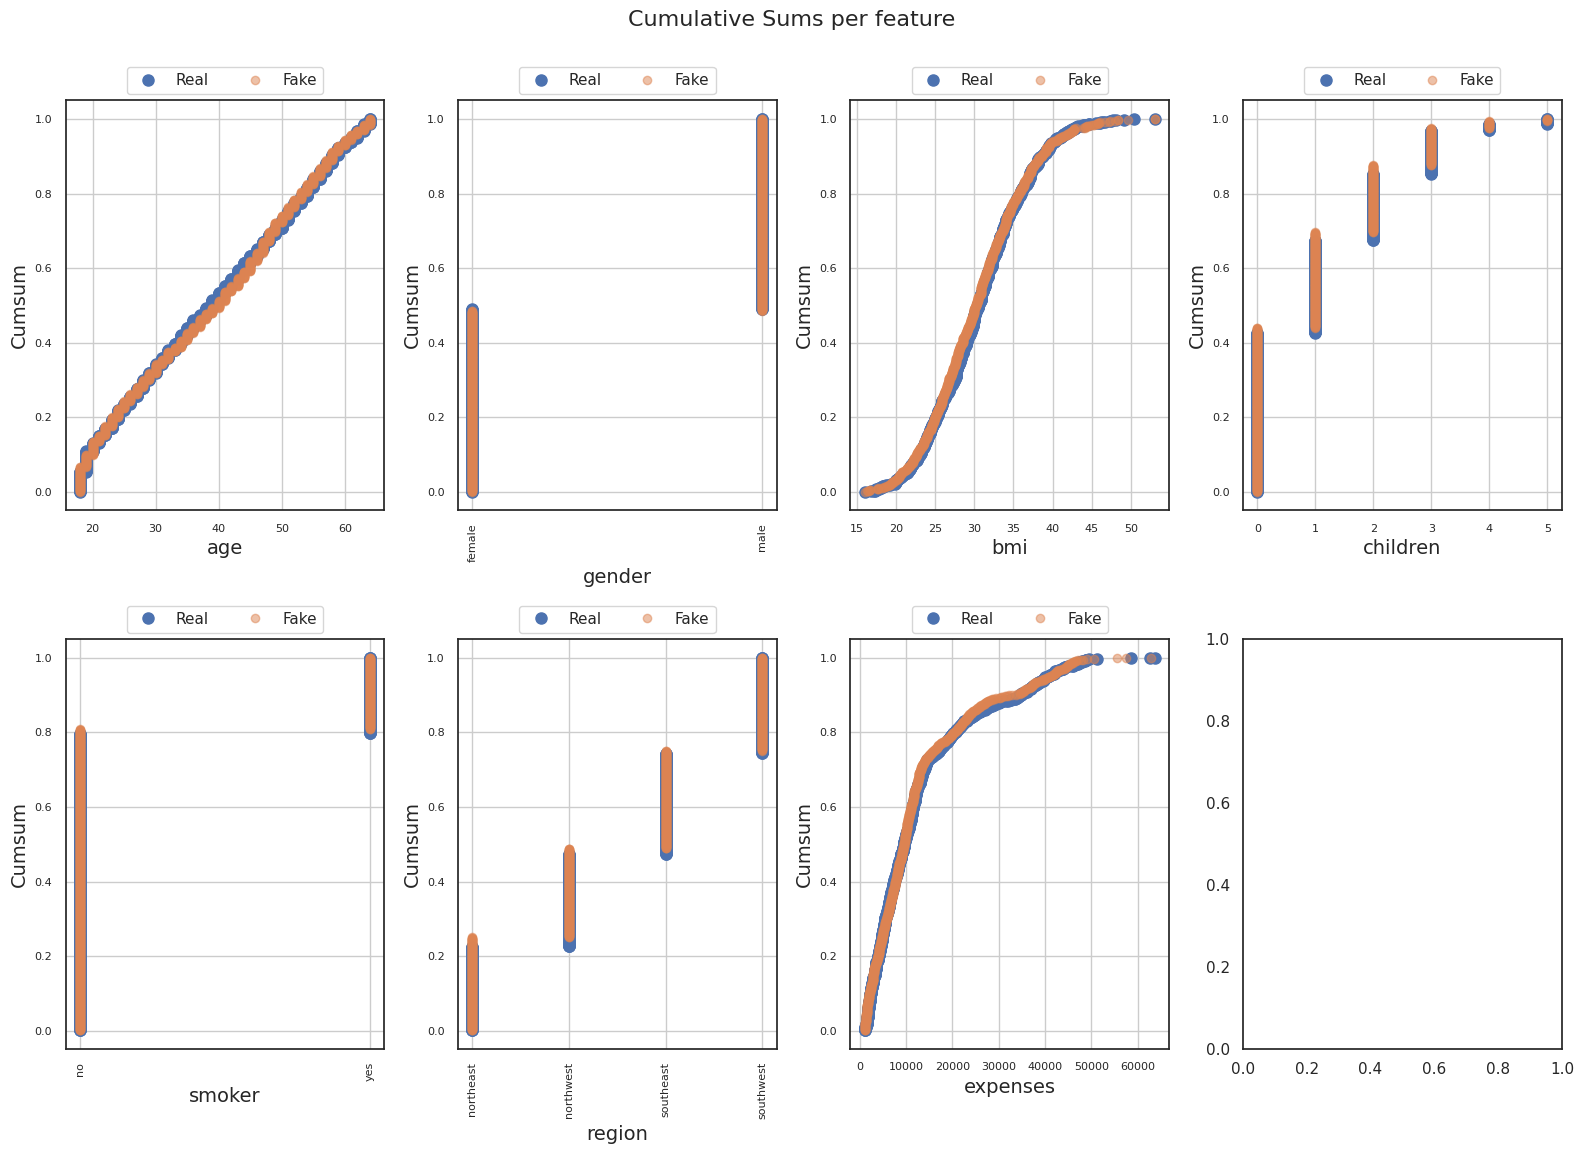

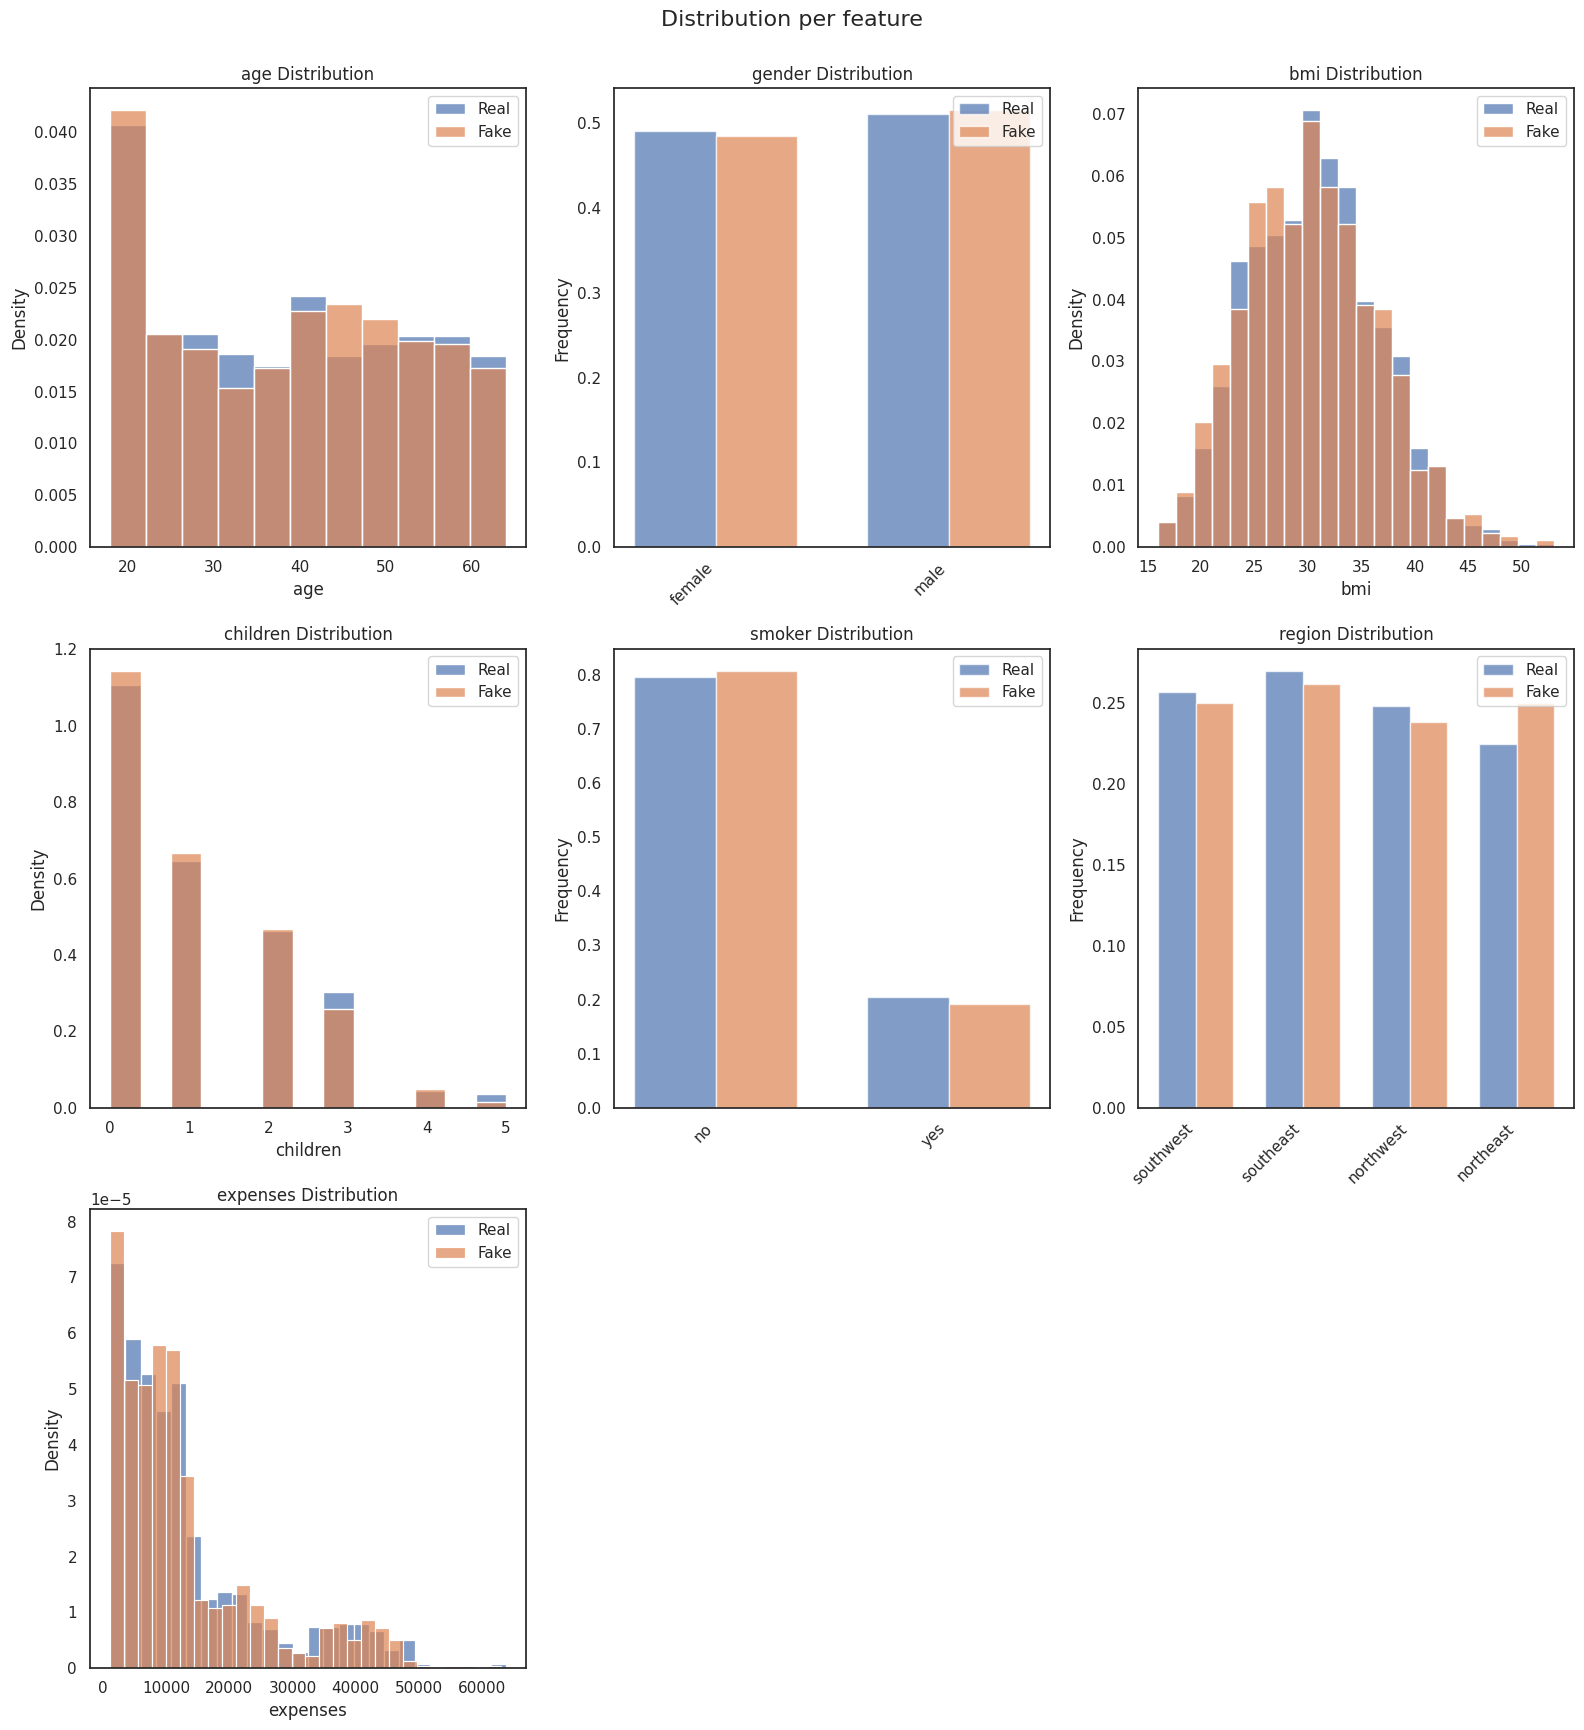

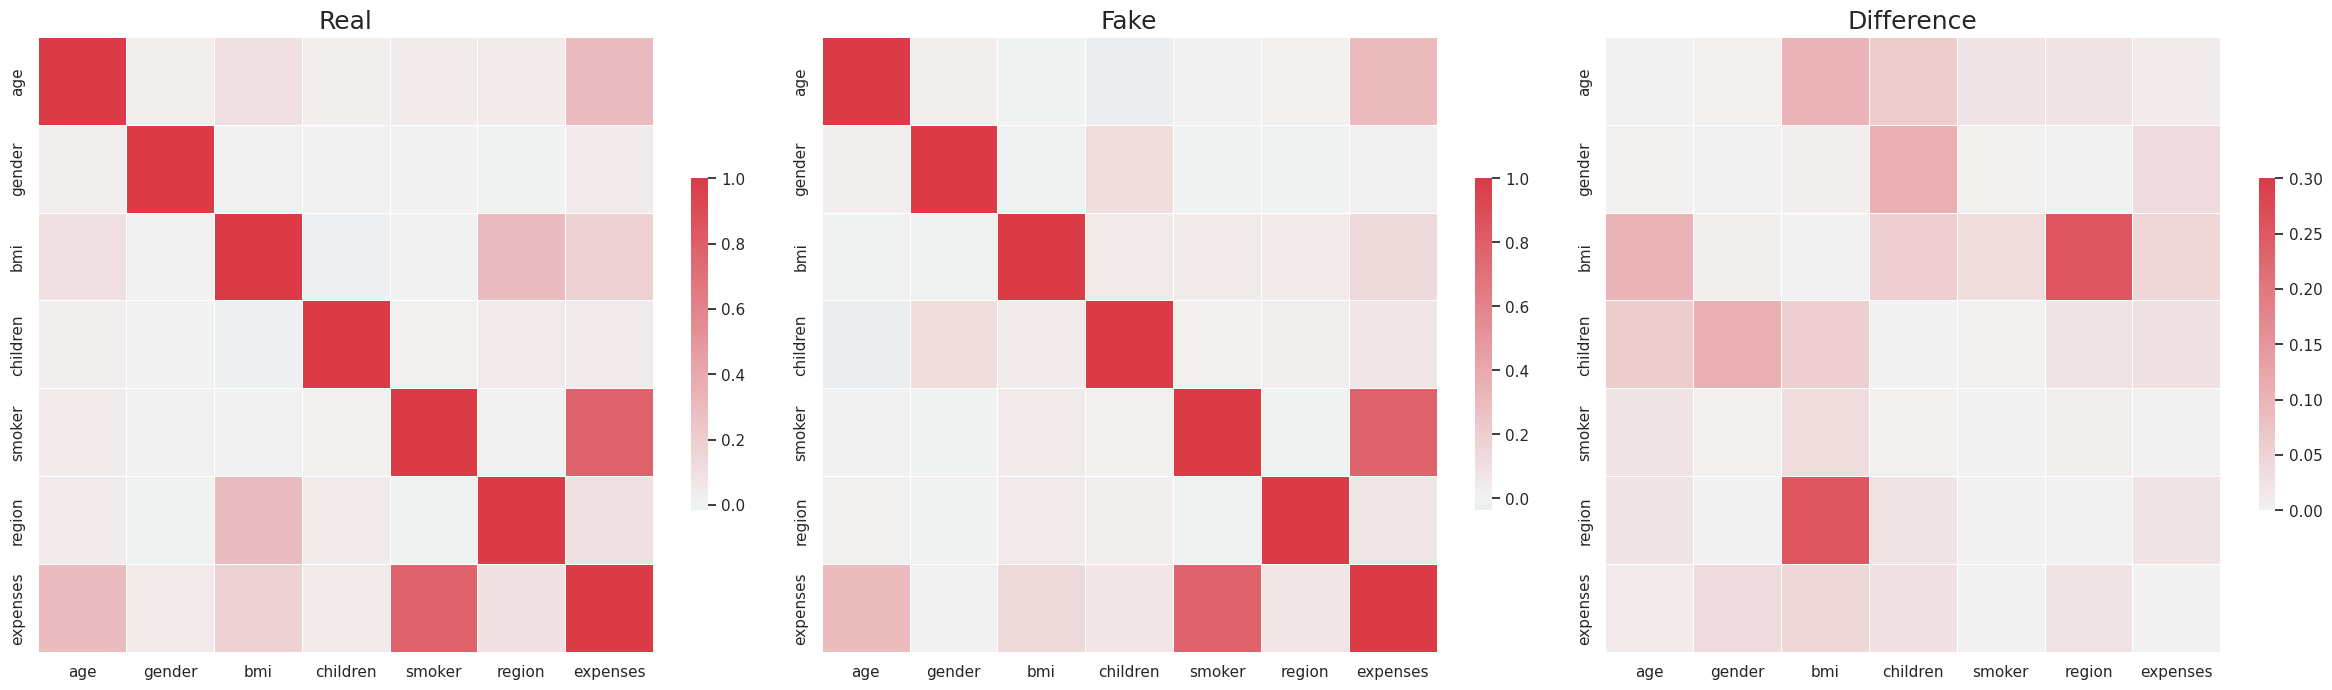

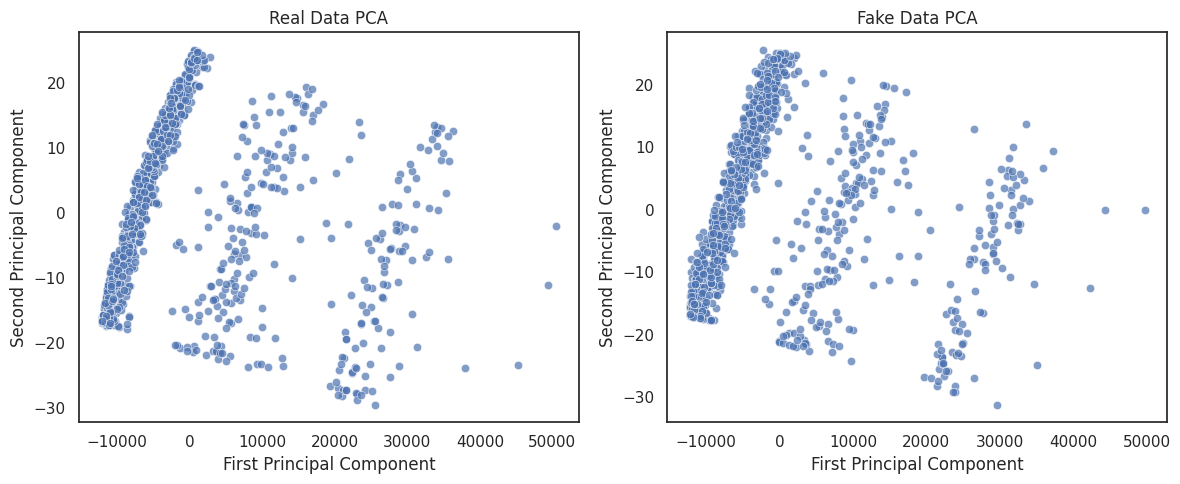

In [37]:
evaluation = table_evaluator.TableEvaluator(ins, ins_syn_fab)
evaluation.visual_evaluation()